# 14. In this problem, you will develop a model to predict whether a given car gets high or low gas mileage based on the Auto data set.

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Auto = pd.read_csv('Auto.csv')

if 'horsepower' in Auto.columns:
  Auto['horsepower'] = pd.to_numeric(Auto['horsepower'], errors='coerce')
Auto = Auto.dropna()

Auto.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


## (a) Create a binary variable, mpg01, that contains a 1 if mpg contains a value above its median, and a 0 if mpg contains a value below its median. You can compute the median using the median() method of the data frame. Note you may fnd it helpful to add a column mpg01 to the data frame by assignment. Assuming you have stored the data frame as Auto, this can be done as follows:


In [109]:
median_mpg = Auto['mpg'].median()
Auto['mpg01'] = (Auto['mpg'] > median_mpg).astype(int)

print(Auto[['mpg', 'mpg01']].head())
print(Auto['mpg01'].value_counts())

    mpg  mpg01
0  18.0      0
1  15.0      0
2  18.0      0
3  16.0      0
4  17.0      0
mpg01
0    196
1    196
Name: count, dtype: int64


## (b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your fndings.

### Observed
| Correlation Category | Features (vs. $\text{mpg01}=1$) | Predictive Summary |
| :--- | :--- | :--- |
| **Highly Negative** ($r < -0.7$) | **weight, displacement, horsepower, cylinders** | Strongest Predictors: Higher values in these features strongly predict low fuel efficiency. |
| **Moderately Positive** ($0.3 < r \leq 0.7$) | **year, origin, acceleration** | Good/Moderate Predictors: Higher values tend to predict higher fuel efficiency, providing supplementary independent information. |


Correlation with mpg01:
mpg             1.000000
mpg01           0.836939
year            0.580541
origin          0.565209
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64


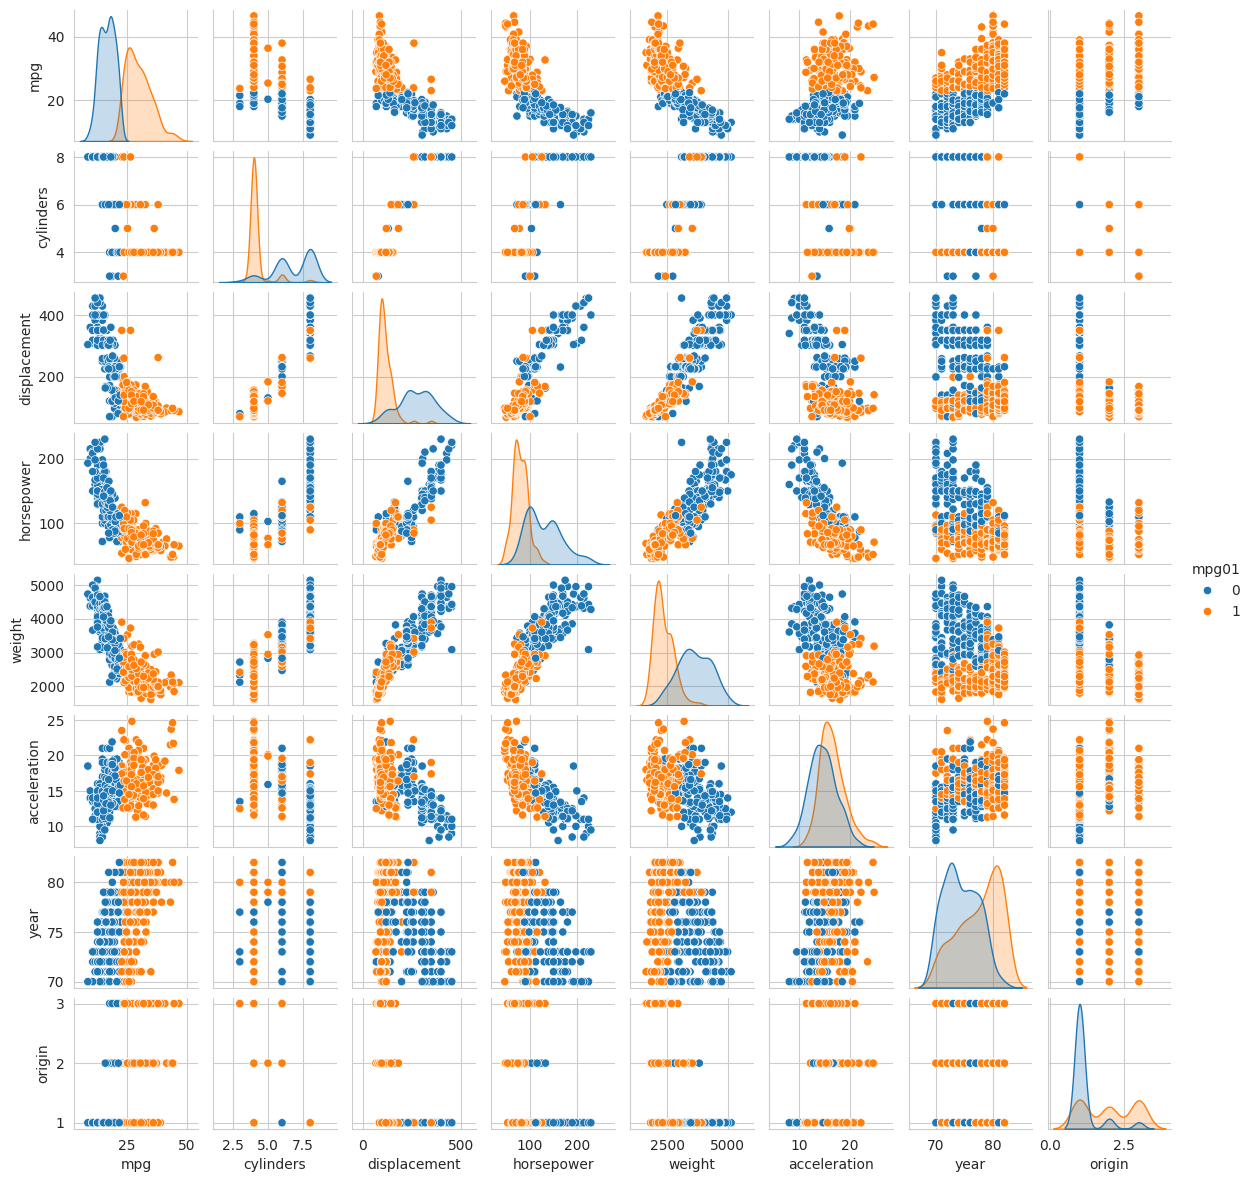

In [110]:
features_to_plot = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin', 'mpg01']

available_features = [col for col in features_to_plot if col in Auto.columns]
Auto_plot = Auto[available_features]

correlation_matrix = Auto.drop('name', axis=1).corr()

print("Correlation with mpg01:")
print(correlation_matrix['mpg'].sort_values(ascending=False))

sns.pairplot(
    Auto_plot,
    hue='mpg01',
    vars=[c for c in available_features if c != 'mpg01'],
    height=1.5,
    diag_kind='kde'
)

## (c) Split the data into a training set and a test set.

In [111]:
import pandas as pd
from sklearn.model_selection import train_test_split

final_features = ['weight', 'cylinders', 'year', 'origin']
X = Auto[final_features]
y = Auto['mpg01']

X_encoded = pd.get_dummies(X, columns=['cylinders', 'origin'], drop_first=True, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=34,
    stratify=y
)

print(f"All data: {len(Auto)}")
print(f"Training: {len(X_train)} (70%)")
print(f"Testing: {len(X_test)} (30%)")

All data: 392
Training: 274 (70%)
Testing: 118 (30%)


In [112]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## (d) Perform LDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [113]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

y_pred_lda = lda.predict(X_test_scaled)

test_accuracy_lda = accuracy_score(y_test, y_pred_lda)
test_error_rate_lda = 1 - test_accuracy_lda

print(f"Test Error Rate (LDA): {test_error_rate_lda:.4f}")

Test Error Rate (LDA): 0.0593


## (e) Perform QDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?


In [114]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)

y_pred_qda = qda.predict(X_test_scaled)

test_accuracy_qda = accuracy_score(y_test, y_pred_qda)
test_error_rate_qda = 1 - test_accuracy_qda

print(f"Test Error Rate (QDA): {test_error_rate_qda:.4f}")

Test Error Rate (QDA): 0.0932


## (f) Perform logistic regression on the training data in order to pre￾dict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [115]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(solver='liblinear', random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)

test_accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
test_error_rate_logreg = 1 - test_accuracy_logreg

print(f"Test Error Rate (Logistic Regression): {test_error_rate_logreg:.4f}")

Test Error Rate (Logistic Regression): 0.0508


## (g) Perform naive Bayes on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [116]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

y_pred_gnb = gnb.predict(X_test_scaled)

test_accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
test_error_rate_gnb = 1 - test_accuracy_gnb

print(f"Test Error Rate (Naive Bayes): {test_error_rate_gnb:.4f}")

Test Error Rate (Naive Bayes): 0.0508


## (h) Perform KNN on the training data, with several values of K, in order to predict mpg01. Use only the variables that seemed most associated with mpg01 in (b). What test errors do you obtain? Which value of K seems to perform the best on this data set?


In [117]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 15, 25]
best_k = -1
min_error = float('inf')
knn_results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred_knn = knn.predict(X_test_scaled)

    test_accuracy_knn = accuracy_score(y_test, y_pred_knn)
    test_error_knn = 1 - test_accuracy_knn

    knn_results[k] = test_error_knn

    print(f"K = {k}: Test Error Rate = {test_error_knn:.4f}")

for k, error in knn_results.items():
  if error < min_error:
    min_error = error
    best_k = k

print(f"\nBest K: {best_k} with Test Error Rate: {min_error:.4f}")

K = 1: Test Error Rate = 0.1271
K = 3: Test Error Rate = 0.1102
K = 5: Test Error Rate = 0.1186
K = 7: Test Error Rate = 0.0763
K = 9: Test Error Rate = 0.0508
K = 15: Test Error Rate = 0.0508
K = 25: Test Error Rate = 0.0593

Best K: 9 with Test Error Rate: 0.0508


In [118]:
models_results = {
    "Model": ["Linear Discriminant Analysis (LDA)", "Quadratic Discriminant Analysis (QDA)",
              "Logistic Regression", "Naive Bayes", f"K-Nearest Neighbors (KNN) (K={best_k})"],
    "Test Error Rate": [test_error_rate_lda, test_error_rate_qda,
                        test_error_rate_logreg, test_error_rate_gnb, min_error]
}

results_df = pd.DataFrame(models_results)

col_widths = {col: results_df[col].astype(str).str.len().max() for col in results_df.columns}
col_widths = {col: max(col_widths[col], len(col)) for col in results_df.columns}

header = "  ".join(f"{col:<{col_widths[col]}}" for col in results_df.columns)
print(header)
print("-" * len(header))

for index, row in results_df.iterrows():
    error_rate_formatted = f"{row['Test Error Rate']:.5f}"
    model_name = row['Model']
    print(f"{model_name:<{col_widths['Model']}}  {error_rate_formatted:<{col_widths['Test Error Rate']}}")


min_error_value = results_df['Test Error Rate'].min()
best_models = results_df.loc[results_df['Test Error Rate'] == min_error_value, 'Model'].tolist()

print(f"\nThe model(s) with the lowest test error rate ({min_error_value:.4f}) is/are:")
for model in best_models:
    print(f" - {model}")

Model                                  Test Error Rate    
----------------------------------------------------------
Linear Discriminant Analysis (LDA)     0.05932            
Quadratic Discriminant Analysis (QDA)  0.09322            
Logistic Regression                    0.05085            
Naive Bayes                            0.05085            
K-Nearest Neighbors (KNN) (K=9)        0.05085            

The model(s) with the lowest test error rate (0.0508) is/are:
 - Logistic Regression
 - Naive Bayes
 - K-Nearest Neighbors (KNN) (K=9)
